In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [5]:
dataset_path = "/content/drive/MyDrive/dataset1 june 3"

In [6]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1600 files belonging to 4 classes.
Using 1280 files for training.
Found 1600 files belonging to 4 classes.
Using 320 files for validation.


In [7]:
class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

['PESTAL~1', 'cordana', 'healthy', 'sigatoka']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [9]:
def channel_attention(input_feature, ratio=8):

    channel = input_feature.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1,1,channel))(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1,1,channel))(max_pool)

    shared_dense_one = layers.Dense(
        channel // ratio,
        activation='relu',
        kernel_initializer='he_normal',
        use_bias=True
    )

    shared_dense_two = layers.Dense(
        channel,
        kernel_initializer='he_normal',
        use_bias=True
    )

    avg_out = shared_dense_two(shared_dense_one(avg_pool))
    max_out = shared_dense_two(shared_dense_one(max_pool))

    cbam_feature = layers.Add()([avg_out, max_out])
    cbam_feature = layers.Activation('sigmoid')(cbam_feature)

    return layers.Multiply()([input_feature, cbam_feature])

In [10]:
def spatial_attention(input_feature):

    avg_pool = tf.reduce_mean(input_feature, axis=3, keepdims=True)
    max_pool = tf.reduce_max(input_feature, axis=3, keepdims=True)

    concat = layers.Concatenate(axis=3)([avg_pool, max_pool])

    cbam_feature = layers.Conv2D(
        filters=1,
        kernel_size=7,
        padding='same',
        activation='sigmoid'
    )(concat)

    return layers.Multiply()([input_feature, cbam_feature])

In [11]:
def cbam_block(feature_map):

    feature_map = channel_attention(feature_map)
    feature_map = spatial_attention(feature_map)

    return feature_map

In [12]:
base_model = MobileNetV3Large(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [14]:
def spatial_attention(input_feature):

    avg_pool = layers.Lambda(
        lambda x: tf.reduce_mean(x, axis=3, keepdims=True)
    )(input_feature)

    max_pool = layers.Lambda(
        lambda x: tf.reduce_max(x, axis=3, keepdims=True)
    )(input_feature)

    concat = layers.Concatenate(axis=3)(
        [avg_pool, max_pool]
    )

    cbam_feature = layers.Conv2D(
        filters=1,
        kernel_size=7,
        strides=1,
        padding='same',
        activation='sigmoid'
    )(concat)

    return layers.Multiply()(
        [input_feature, cbam_feature]
    )

In [15]:
dummy = tf.random.normal((1,7,7,960))

out = cbam_block(dummy)

print(out.shape)

(1, 7, 7, 960)


In [16]:
inputs = layers.Input(shape=(224,224,3))

x = preprocess_input(inputs)

x = base_model(x)

x = cbam_block(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ input_layer_2[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1, 1, 960) │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 1, 1, 960) │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1, 1, 120) │    115,320 │ reshape_4[0][0],  │
│                     │                   │            │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 1, 960) │    116,160 │ dense_4[0][0],    │
│                     │                   │            │ dense_4[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 1, 1, 960) │          0 │ dense_5[0][0],    │
│                     │                   │            │ dense_5[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 1, 1, 960) │          0 │ add_10[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_11         │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ activation_22[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_11[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_11[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 7, 7, 2)   │          0 │ lambda_2[0][0],   │
│ (Concatenate)       │                   │            │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 1)   │         99 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_12         │ (None, 7, 7, 960) │          0 │ multiply_11[0][0… │
│ (Multiply)          │                   │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ multiply_12[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    246,016 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense_6[0][0]   

 Total params: 3,474,975 (13.26 MB)

 Trainable params: 478,623 (1.83 MB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 328s 8s/step - accuracy: 0.8320 - loss: 0.4922 - val_accuracy: 0.9406 - val_loss: 0.1697
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.9625 - loss: 0.1122 - val_accuracy: 0.9625 - val_loss: 0.1207
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.9844 - loss: 0.0516 - val_accuracy: 0.9688 - val_loss: 0.0780
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.9922 - loss: 0.0282 - val_accuracy: 0.9656 - val_loss: 0.0878
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.9961 - loss: 0.0160 - val_accuracy: 0.9688 - val_loss: 0.0804
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9961 - loss: 0.0182 - val_accuracy: 0.9719 - val_loss: 0.0795
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.9984 - loss: 0.0125 - val_accuracy: 0.9750 - val_loss: 0.0661
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.9992 - loss: 0.0056 - val_accuracy: 0.9

In [20]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 267ms/step - accuracy: 0.9766 - loss: 0.0790 - val_accuracy: 0.9781 - val_loss: 0.0882
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.9820 - loss: 0.0522 - val_accuracy: 0.9781 - val_loss: 0.0870
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.9891 - loss: 0.0356 - val_accuracy: 0.9781 - val_loss: 0.0856
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.9883 - loss: 0.0308 - val_accuracy: 0.9781 - val_loss: 0.0848
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.9906 - loss: 0.0312 - val_accuracy: 0.9781 - val_loss: 0.0833
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.9945 - loss: 0.0179 - val_accuracy: 0.9812 - val_loss: 0.0822
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.9922 - loss: 0.0224 - val_accuracy: 0.9812 - val_loss: 0.0811
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.9945 - loss: 0.0169 - val_accuracy: 0

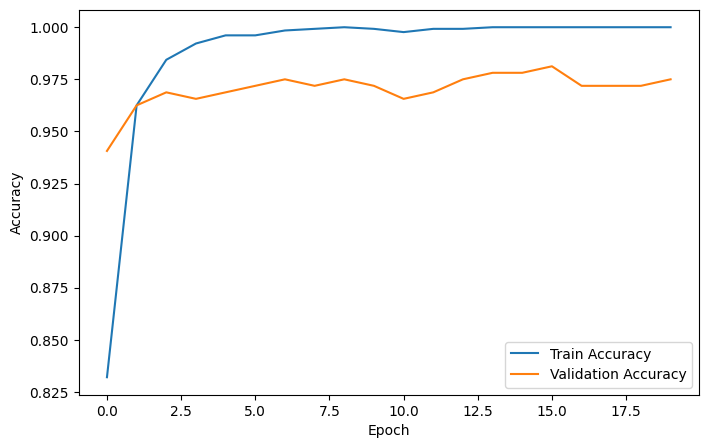

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

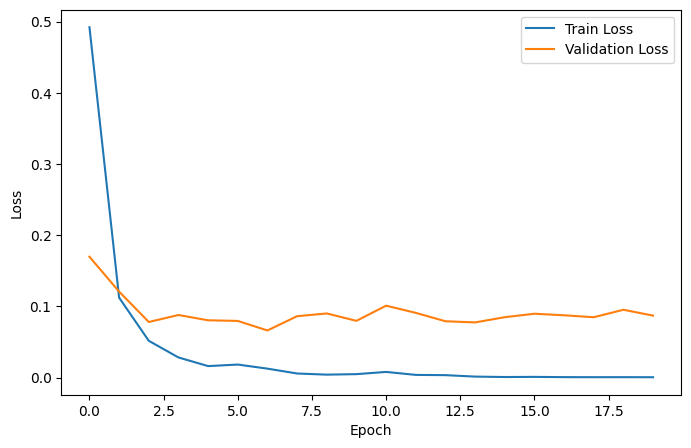

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [25]:
loss, acc = model.evaluate(val_ds)

print("Validation Accuracy:", acc)
print("Validation Loss:", loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.9781 - loss: 0.0793
Validation Accuracy: 0.9781249761581421
Validation Loss: 0.07926660776138306


In [26]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [28]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[70  0  0  1]
 [ 0 75  0  2]
 [ 2  0 77  0]
 [ 1  1  0 91]]


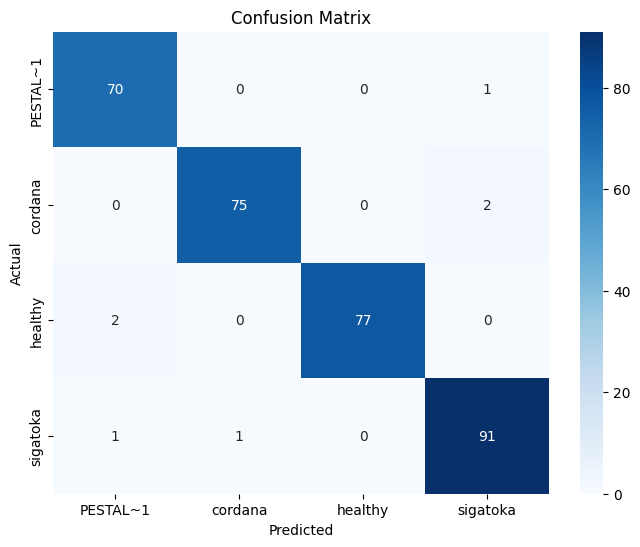

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [30]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    PESTAL~1       0.96      0.99      0.97        71
     cordana       0.99      0.97      0.98        77
     healthy       1.00      0.97      0.99        79
    sigatoka       0.97      0.98      0.97        93

    accuracy                           0.98       320
   macro avg       0.98      0.98      0.98       320
weighted avg       0.98      0.98      0.98       320



In [32]:
model.save("/content/drive/MyDrive/MobileNetV3_CBAM.keras")

In [34]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Difference:", train_acc - val_acc)

Train Accuracy: 1.0
Validation Accuracy: 0.9750000238418579
Difference: 0.02499997615814209


In [35]:
x = layers.Dropout(0.5)(x)

In [36]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [37]:
tf.keras.optimizers.Adam(1e-5)

In [38]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [40]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [42]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.9977 - loss: 0.0114 - val_accuracy: 0.9781 - val_loss: 0.0789 - learning_rate: 1.0000e-05
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 0.9781 - val_loss: 0.0788 - learning_rate: 1.0000e-05
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.9969 - loss: 0.0097 - val_accuracy: 0.9781 - val_loss: 0.0774 - learning_rate: 1.0000e-05
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9984 - loss: 0.0083 - val_accuracy: 0.9781 - val_loss: 0.0774 - learning_rate: 1.0000e-05
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.9992 - loss: 0.0073 - val_accuracy: 0.9781 - val_loss: 0.0773 - learning_rate: 1.0000e-05
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.9953 - loss: 0.0134 - val_accuracy: 0.9750 - val_loss: 0.0770 - learning_rate: 1.0000e-05
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 

In [43]:
loss, acc = model.evaluate(val_ds)

print("Validation Accuracy:", acc)
print("Validation Loss:", loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.9812 - loss: 0.0684
Validation Accuracy: 0.981249988079071
Validation Loss: 0.06844861805438995


In [44]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Difference:", train_acc - val_acc)

Train Accuracy: 0.999218761920929
Validation Accuracy: 0.981249988079071
Difference: 0.01796877384185791


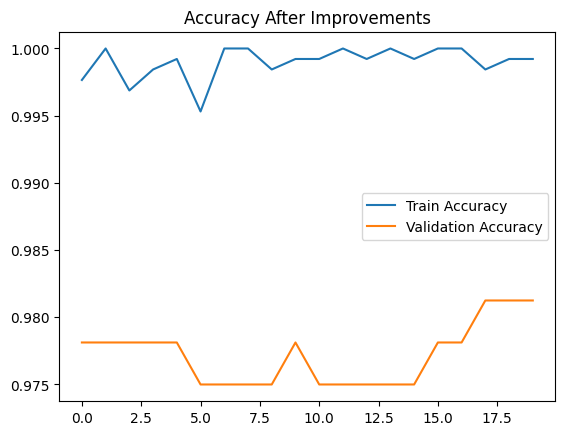

In [45]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy After Improvements")
plt.show()

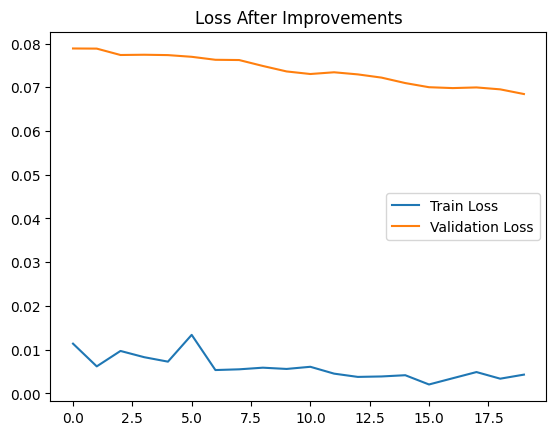

In [46]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss After Improvements")
plt.show()

In [47]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[70  0  0  1]
 [ 0 75  0  2]
 [ 3  0 76  0]
 [ 0  0  0 93]]


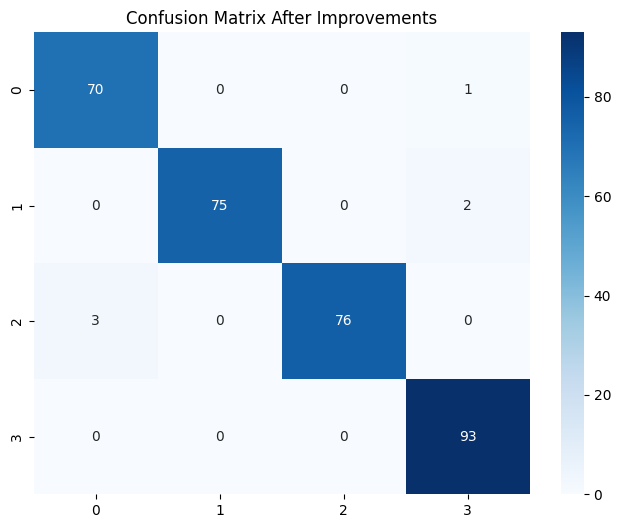

In [48]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix After Improvements")
plt.show()